In [58]:
def mnk(X, Y):
    N = len(X)
    
    XY = [X[i]*Y[i] for i in range(N)]
    X2 = [x*x for x in X]
    Y2 = [y*y for y in Y]
    
    _xy = sum(XY)/len(XY)
    _x = sum(X)/N
    _y = sum(Y)/N
    _x2 = sum(X2)/N
    _y2 = sum(Y2)/N

    b = (_xy - _x*_y)/(_x2 - _x*_x)
    a = _y - b*_x

    sb = (((_y2 - _y**2)/(_x2 - _x**2) - b**2)*(1/N))**0.5
    sa = sb*(_x2-_x*_x)**0.5
    
    return (b, a, sb, sa)

In [59]:
file = open('0.txt', 'r')
A = list(list())
M = list()
idx = -1
for line in file:
    if line[0].isdigit():
        n = int(line)
        if n > 10000:
            A.append(list())
            idx +=1
            M.append(n)
        else: A[idx].append(n)
file.close()
print(A)

[[136, 274, 409, 550, 685, 828, 964, 1092, 1246, 1360], [161, 322, 483, 645, 806, 969, 1132, 1290, 1463, 1628], [187, 373, 561, 748, 936, 1125, 1314, 1503, 1694, 1885], [208, 416, 624, 832, 1041, 1249, 1460, 1670, 1881, 2092]]


In [60]:
df = 1 # Гц
dm = 3 # 0,1 г
g = 9.815
F = [m*g/10000 for m in M]
print(F)

[10.5364025, 14.960022999999998, 19.8586895, 24.586575]


In [61]:
N = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
B = list()
for a in A:
    b, a, sb, sa = mnk(N, a)
    B.append([b,a,sb,sa])
print(B)

[[137.0909090909091, 0.39999999999997726, 0.647810467810402, 1.8606939077099807], [162.7212121212121, -5.066666666666492, 0.38453100720460875, 1.1044812302116205], [188.64242424242437, -4.933333333334076, 0.22115815032361485, 0.63522842466324], [209.29090909090917, -3.8000000000004093, 0.19883960893473623, 0.5711232950693576]]


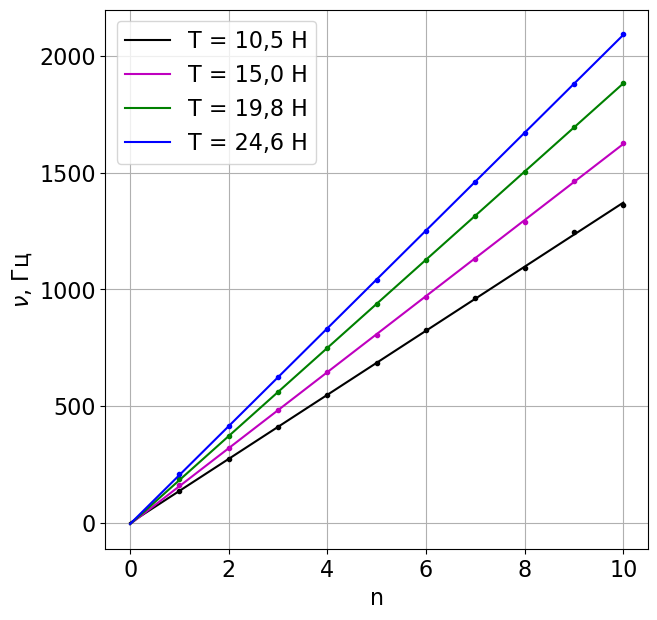

In [65]:
Y1 = A[0]
Y2 = A[1]
Y3 = A[2]
Y4 = A[3]
X = N
ery = df

#K1 = b
#B1 = a

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.size'] = 16 
plt.figure(figsize=(7,7))


plt.ylabel(r"$\nu$, Гц")
plt.xlabel("n")

plt.grid(visible=True, which='major', axis='both', alpha=1)
plt.grid(visible=True, which='minor', axis='both', alpha=1)

color = ['.k', '.m', '.g', '.b']
label = ['T = 10,5 Н', 'Т = 15,0 Н', 'Т = 19,8 Н', 'Т = 24,6 Н']

for i in range(0, 4):
    plt.plot(X, A[i], color[i])
    x = np.linspace(0, 10, 100)
    y = B[i][0]*x + B[i][1]
    plt.plot(x,y, color[i][1:], label=label[i])

plt.legend()
plt.savefig('example.png')
plt.show()

In [63]:
L = 0.5 #m
dL = 0.001
eL = dL/L
U = list()
dU = list()
for i in range(4):
    b = B[i][0]
    sb = B[i][2]
    cb = b*(df/min(A[i]))
    Sb = (sb**2 + cb**2)**0.5
    eb = Sb/b

    u = 2*L*b
    eu = (eb**2 + eL**2)**0.5
    du = u*eu
    u2 = u**2
    eu2 = eu*2
    du2 = u2*eu2
    U.append(u2)
    dU.append(du2)
    print(u, '+-', du)

137.0909090909091 +- 1.2292034799326026
162.7212121212121 +- 1.1292797157258838
188.64242424242437 +- 1.0994989588092903
209.29090909090917 +- 1.1077901579666938


1.7885455518309539 -0.10828486382827052 0.012323559569779756 0.06483799488512136


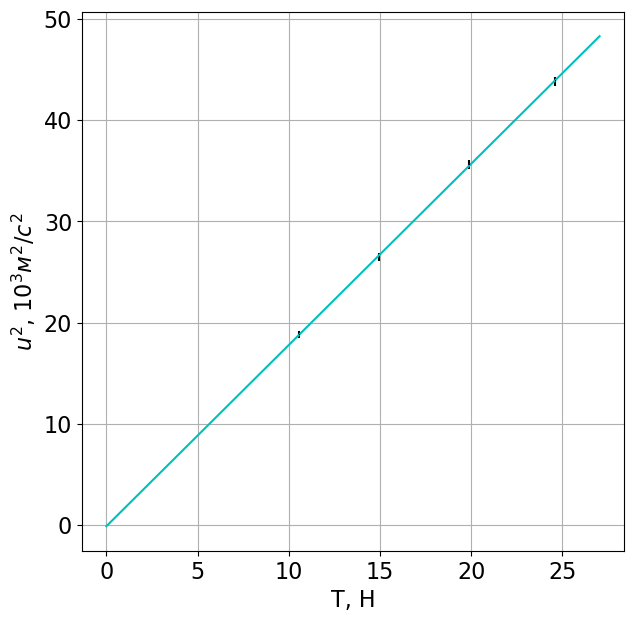

In [64]:
Y = [u/1000 for u in U] 
X = [f for f in F]
ery = [du/1000 for du in dU]

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.size'] = 16 
plt.figure(figsize=(7,7))


plt.ylabel(r"$u^2$, $10^{3} {м}^2 / {c}^2$")
plt.xlabel("T, Н")

plt.grid(visible=True, which='major', axis='both', alpha=1)
plt.grid(visible=True, which='minor', axis='both', alpha=1)

plt.errorbar(X, Y, yerr = ery, fmt=',k')


b, a, sb, sa = mnk(X, Y)

print(b, a, sb, sa)

x = np.linspace(0, max(X)*1.1, 100)
y = b*x + a
plt.plot(x,y, 'c')

#plt.legend()
plt.savefig('example.png')
plt.show()

In [68]:
r = 1/b/1000
eu = max([dU[i]/U[i] for i in range(4)])

er = ((sb/b)**2 +eu**2 )**0.5
print(r*1000000, r*er*1000000)

559.1135204671131 3.8524424321718262
